In [1]:
import os
import random
import numpy as np
import torch
import torchvision
from torchvision import datasets, transforms
from torch import nn
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
from pathlib import Path
import csv
import json

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Torch:", torch.__version__)


Device: cpu
Torch: 2.9.1


In [2]:
ART = Path("artifacts")
FIG = ART / "figures"
ART.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

RUNS_CSV = ART / "runs.csv"


In [3]:
transform = transforms.ToTensor()

train_full = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_ds = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print("Train size:", len(train_full))
print("Test size:", len(test_ds))


Train size: 60000
Test size: 10000


In [4]:
val_ratio = 0.2
n_total = len(train_full)
n_val = int(n_total * val_ratio)
n_train = n_total - n_val

generator = torch.Generator().manual_seed(SEED)
train_ds, val_ds = random_split(train_full, [n_train, n_val], generator=generator)

print("Train:", len(train_ds), "Val:", len(val_ds))


Train: 48000 Val: 12000


In [5]:
BATCH_SIZE = 128

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

xb, yb = next(iter(train_loader))
print("Batch x shape:", xb.shape)
print("Batch y shape:", yb.shape)


Batch x shape: torch.Size([128, 1, 28, 28])
Batch y shape: torch.Size([128])


In [6]:
class MLP(nn.Module):
    def __init__(self, hidden_sizes=(256, 128), dropout=0.0, batchnorm=False):
        super().__init__()
        layers = []
        in_features = 28 * 28

        prev = in_features
        for h in hidden_sizes:
            layers.append(nn.Linear(prev, h))
            if batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h

        layers.append(nn.Linear(prev, 10))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)


In [7]:
def accuracy(logits, y):
    return (logits.argmax(1) == y).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    total_acc = 0
    n = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy(logits, y)
        n += 1

    return total_loss / n, total_acc / n

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    total_acc = 0
    n = 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item()
        total_acc += accuracy(logits, y)
        n += 1

    return total_loss / n, total_acc / n


In [8]:
def log_run(row):
    file_exists = RUNS_CSV.exists()
    fieldnames = [
        "experiment_id", "dataset", "seed", "model_summary",
        "optimizer", "lr", "momentum", "weight_decay",
        "epochs_trained", "best_val_accuracy", "best_val_loss"
    ]

    with RUNS_CSV.open("a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        if not file_exists:
            writer.writeheader()
        writer.writerow(row)


In [9]:
def run_experiment(
    experiment_id,
    hidden=(256,128),
    dropout=0.0,
    batchnorm=False,
    optimizer_name="Adam",
    lr=1e-3,
    momentum=0.0,
    weight_decay=0.0,
    max_epochs=20,
    early_stopping=False,
    patience=5
):
    model = MLP(hidden_sizes=hidden, dropout=dropout, batchnorm=batchnorm).to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "Adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)

    best_val_acc = 0
    best_val_loss = float("inf")
    best_epoch = 0
    history = []

    for epoch in range(max_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history.append((train_loss, val_loss, train_acc, val_acc))

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_epoch = epoch
            torch.save(model.state_dict(), ART / "best_model.pt")
            json.dump({
                "hidden": hidden,
                "dropout": dropout,
                "batchnorm": batchnorm,
                "optimizer": optimizer_name,
                "lr": lr,
                "momentum": momentum,
                "weight_decay": weight_decay,
                "seed": SEED,
                "dataset": "MNIST"
            }, open(ART / "best_config.json", "w"))

        if early_stopping and epoch - best_epoch >= patience:
            break

    log_run({
        "experiment_id": experiment_id,
        "dataset": "MNIST",
        "seed": SEED,
        "model_summary": f"{hidden}, dropout={dropout}, bn={batchnorm}",
        "optimizer": optimizer_name,
        "lr": lr,
        "momentum": momentum,
        "weight_decay": weight_decay,
        "epochs_trained": epoch + 1,
        "best_val_accuracy": best_val_acc,
        "best_val_loss": best_val_loss
    })

    return history


In [10]:
hist_E1 = run_experiment("E1", dropout=0.0, batchnorm=False)
hist_E2 = run_experiment("E2", dropout=0.3, batchnorm=False)
hist_E3 = run_experiment("E3", dropout=0.0, batchnorm=True)
hist_E4 = run_experiment("E4", dropout=0.3, batchnorm=False, early_stopping=True)


In [11]:
hist_O1 = run_experiment("O1", lr=1e-1)
hist_O2 = run_experiment("O2", lr=1e-5)
hist_O3 = run_experiment("O3", optimizer_name="SGD", lr=1e-2, momentum=0.9, weight_decay=1e-4)


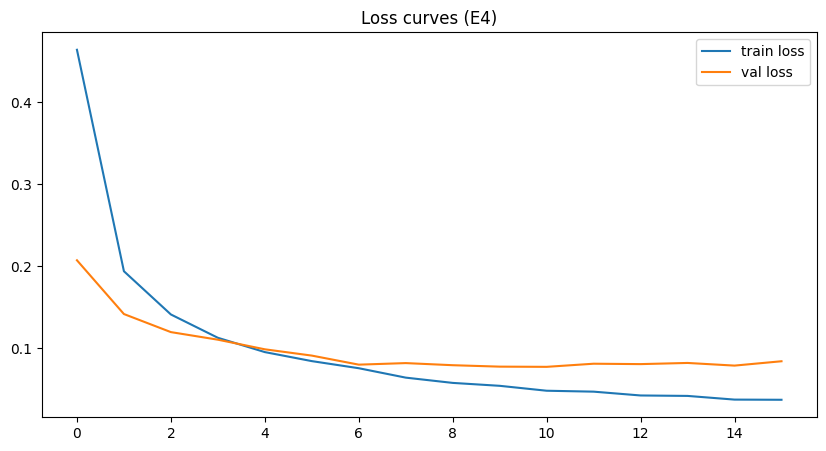

In [12]:
train_loss = [x[0] for x in hist_E4]
val_loss = [x[1] for x in hist_E4]
train_acc = [x[2] for x in hist_E4]
val_acc = [x[3] for x in hist_E4]

plt.figure(figsize=(10,5))
plt.plot(train_loss, label="train loss")
plt.plot(val_loss, label="val loss")
plt.legend()
plt.title("Loss curves (E4)")
plt.savefig(FIG / "curves_best.png")
plt.show()


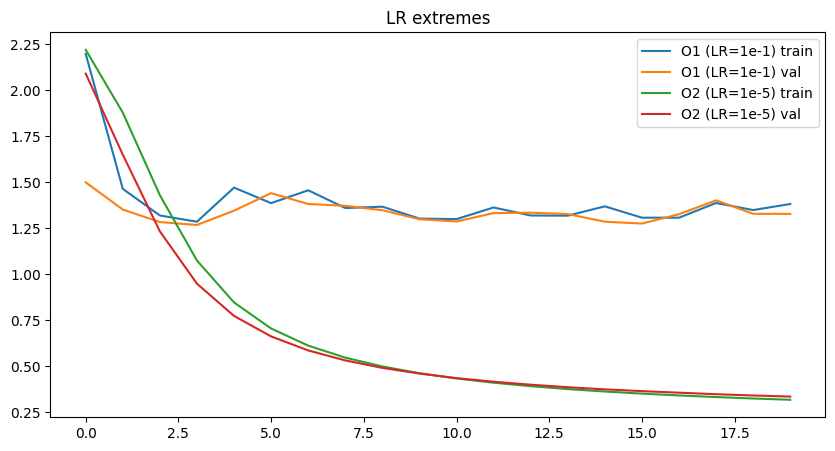

In [13]:
def plot_lr_extremes(hist, label):
    train_loss = [x[0] for x in hist]
    val_loss = [x[1] for x in hist]
    plt.plot(train_loss, label=f"{label} train")
    plt.plot(val_loss, label=f"{label} val")

plt.figure(figsize=(10,5))
plot_lr_extremes(hist_O1, "O1 (LR=1e-1)")
plot_lr_extremes(hist_O2, "O2 (LR=1e-5)")
plt.legend()
plt.title("LR extremes")
plt.savefig(FIG / "curves_lr_extremes.png")
plt.show()


In [16]:
# загрузка конфигурации лучшей модели
config = json.load(open(ART / "best_config.json"))

best_model = MLP(
    hidden_sizes=tuple(config["hidden"]),
    dropout=config["dropout"],
    batchnorm=config["batchnorm"]
).to(device)

# загрузка весов
best_model.load_state_dict(
    torch.load(ART / "best_model.pt", map_location=device)
)

criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(best_model, test_loader, criterion)

print("Test accuracy:", test_acc)

Test accuracy: 0.9761669303797469
